# Training results plots (v4)

Regenerate presentation figures from **`02_model_development_v4.ipynb`** outputs and **SHAP/MOA** results from `03_shap_moa_analysis_v2_426.ipynb`.

**Training inputs:** merged CSVs under `model_results_v4/` (auto-detected).  
**SHAP inputs:** parquets/CSVs under `data/shap_results_426/`.

Figures are saved to `plots/` and mirrored under the results folders.

In [1]:
import importlib.util
import os
import sys
from pathlib import Path

# Writable matplotlib cache (avoids permission issues in some IDE kernels)
PROJECT_DIR = Path.cwd()
MPLCONFIG_DIR = PROJECT_DIR / "data" / "model_results_v4" / ".matplotlib"
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR))

REQUIRED = ["pandas", "numpy", "matplotlib", "seaborn", "scipy", "sklearn", "pyarrow"]
missing = [m for m in REQUIRED if importlib.util.find_spec(m) is None]
if missing:
    raise ImportError(
        "Missing packages: "
        + ", ".join(missing)
        + f"\nInstall with: {sys.executable} -m pip install "
        + " ".join(missing)
    )
print("All required packages are available.")

All required packages are available.


In [2]:
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# Omics layer colours (used in SHAP gene plots)
LAYER_COLORS = {
    "expr": "steelblue",
    "mut": "crimson",
    "cnv": "forestgreen",
}

PROJECT_DIR = Path(".").resolve()
PROCESSED_DIR = PROJECT_DIR / "data" / "processed_no_prot_no_methyl"
PLOTS_DIR = PROJECT_DIR / "plots"
SHAP_DIR = PROJECT_DIR / "data" / "shap_results_426"
SHAP_FIGURE_DIR = SHAP_DIR / "figures"


def discover_results_dir() -> Path:
    """Find folder containing merged cv_metrics.csv."""
    candidates = [
        PROJECT_DIR / "data" / "model_results_v4",
        PROJECT_DIR / "model_results_v4",
        PROJECT_DIR / "data" / "model_results_v4 ",
    ]
    for path in candidates:
        if (path / "cv_metrics.csv").exists():
            return path
    raise FileNotFoundError(
        "Could not find cv_metrics.csv. Expected one of:\n"
        + "\n".join(f"  - {p / 'cv_metrics.csv'}" for p in candidates)
    )


RESULTS_DIR = discover_results_dir()
FIGURE_DIR = RESULTS_DIR / "figures"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
SHAP_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"RESULTS_DIR  : {RESULTS_DIR}")
print(f"PROCESSED_DIR: {PROCESSED_DIR.resolve()}")
print(f"PLOTS_DIR    : {PLOTS_DIR.resolve()}")
print(f"SHAP_DIR     : {SHAP_DIR.resolve()}")

Matplotlib is building the font cache; this may take a moment.


RESULTS_DIR  : /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/data/model_results_v4
PROCESSED_DIR: /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/data/processed_no_prot_no_methyl
PLOTS_DIR    : /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/plots
SHAP_DIR     : /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/data/shap_results_426


In [3]:
def load_csv(name: str, required: bool = True, base: Optional[Path] = None) -> Optional[pd.DataFrame]:
    base = base or RESULTS_DIR
    path = base / name
    if not path.exists():
        msg = f"Missing: {path}"
        if required:
            raise FileNotFoundError(msg)
        print(msg)
        return None
    df = pd.read_csv(path)
    print(f"Loaded {path.name}: {df.shape}")
    return df


def save_figure(fig, filename: str, mirror_dirs=(PLOTS_DIR, FIGURE_DIR)):
    for directory in mirror_dirs:
        directory.mkdir(parents=True, exist_ok=True)
        out = directory / filename
        fig.savefig(out, dpi=180, bbox_inches="tight")
    print(f"Saved: {PLOTS_DIR / filename}")


cv_metrics = load_csv("cv_metrics.csv")
cv_predictions = load_csv("cv_predictions.csv")
learned_weights = load_csv("learned_late_fusion_weights.csv", required=False)
top10 = load_csv("top10_model_strategy_summary.csv", required=False)
within_lineage_df = load_csv("within_lineage_metrics.csv", required=False)
within_comparison = load_csv("within_lineage_comparison.csv", required=False)

meta_path = PROCESSED_DIR / "cell_metadata.parquet"
cell_metadata = pd.read_parquet(meta_path) if meta_path.exists() else None
if cell_metadata is not None:
    if "ModelID" in cell_metadata.columns:
        cell_metadata = cell_metadata.set_index("ModelID")
    print(f"Loaded cell_metadata: {cell_metadata.shape}")
else:
    print(f"No cell metadata at {meta_path} — within-lineage plot uses precomputed CSV only")

print(f"\nCompounds in cv_metrics: {cv_metrics['compound'].nunique()}")

Loaded cv_metrics.csv: (93720, 12)
Loaded cv_predictions.csv: (8912552, 8)
Loaded learned_late_fusion_weights.csv: (12780, 7)
Loaded top10_model_strategy_summary.csv: (10, 9)
Loaded within_lineage_metrics.csv: (201968, 10)
Loaded within_lineage_comparison.csv: (32, 5)
Loaded cell_metadata: (574, 8)

Compounds in cv_metrics: 426


## 1. CV performance — Pearson r by strategy / model family

Saved: /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/plots/cv_pearson_by_strategy.png


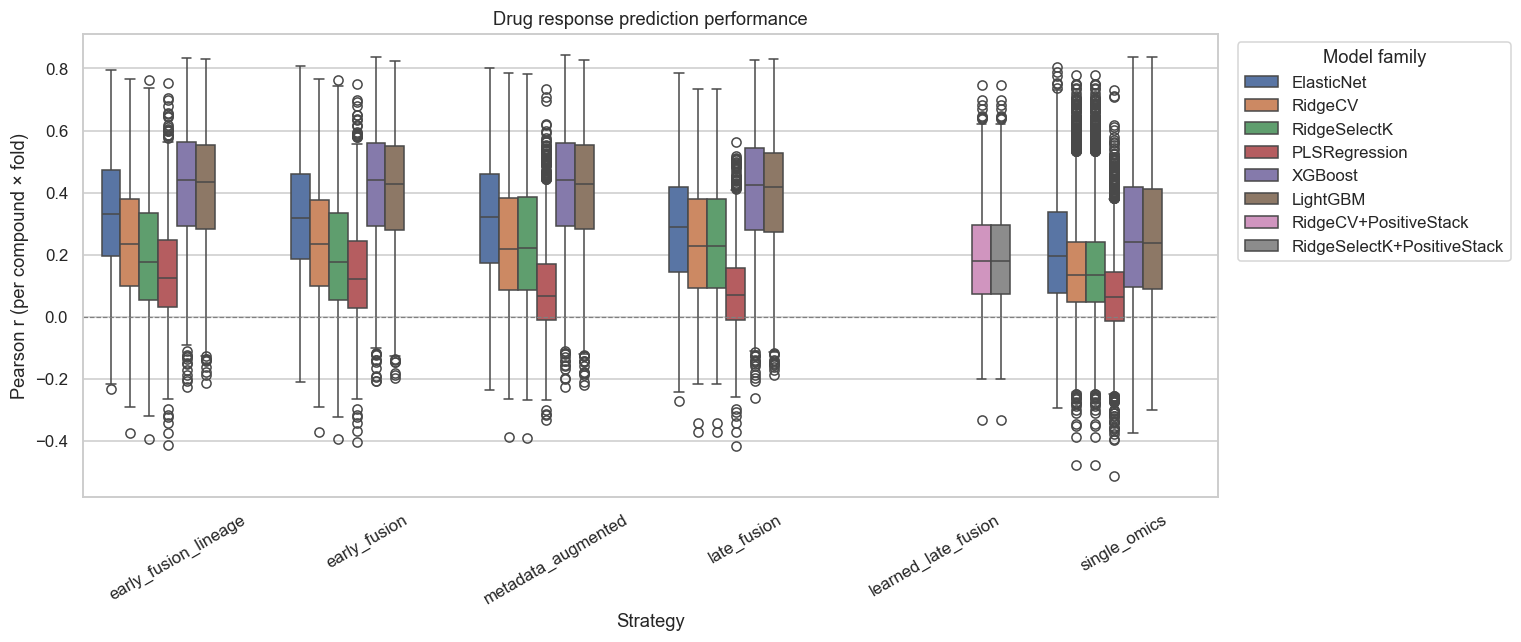

In [4]:
TOP_N_STRATEGIES = 8
top_strategies = (
    cv_metrics.groupby("strategy")["pearson"]
    .mean().sort_values(ascending=False).head(TOP_N_STRATEGIES).index
)
plot_data = cv_metrics[cv_metrics["strategy"].isin(top_strategies)].copy()

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=plot_data, x="strategy", y="pearson", hue="model_family",
    order=list(top_strategies), ax=ax,
)
ax.set_xlabel("Strategy")
ax.set_ylabel("Pearson r (per compound × fold)")
ax.set_title("Drug response prediction performance")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.tick_params(axis="x", rotation=30)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", title="Model family")
plt.tight_layout()

save_figure(fig, "cv_pearson_by_strategy.png")
plt.show()

## 2. Top 10 configs + best model summary

,rank,model_family,strategy,omics_layer,mean_pearson,mean_spearman,mean_r2,mean_rmse,n_folds
0,1,XGBoost,early_fusion,multiomics,0.4175,0.3700,0.1800,0.0855,2130
1,2,XGBoost,early_fusion_lineage,multiomics_plus_lineage,0.4174,0.3693,0.1798,0.0855,2130
2,3,XGBoost,metadata_augmented,expr_plus_lineage,0.4174,0.3694,0.1789,0.0856,2130
3,4,XGBoost,single_omics,expr,0.4163,0.3683,0.1778,0.0857,2130
4,5,LightGBM,early_fusion_lineage,multiomics_plus_lineage,0.4087,0.3615,0.1727,0.0860,2130
5,6,LightGBM,early_fusion,multiomics,0.4085,0.3612,0.1723,0.0861,2130
6,7,LightGBM,single_omics,expr,0.4054,0.3576,0.1690,0.0863,2130
7,8,LightGBM,metadata_augmented,expr_plus_lineage,0.4052,0.3579,0.1691,0.0863,2130
8,9,XGBoost,late_fusion,late_fusion(expr_mut_cnv),0.4016,0.3507,0.1397,0.0885,2130
9,10,LightGBM,late_fusion,late_fusion(expr_mut_cnv),0.3924,0.3418,0.1320,0.0889,2130



Best: XGBoost / early_fusion / multiomics (mean Pearson = 0.4175)
Saved: /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/plots/top5_model_configs.png


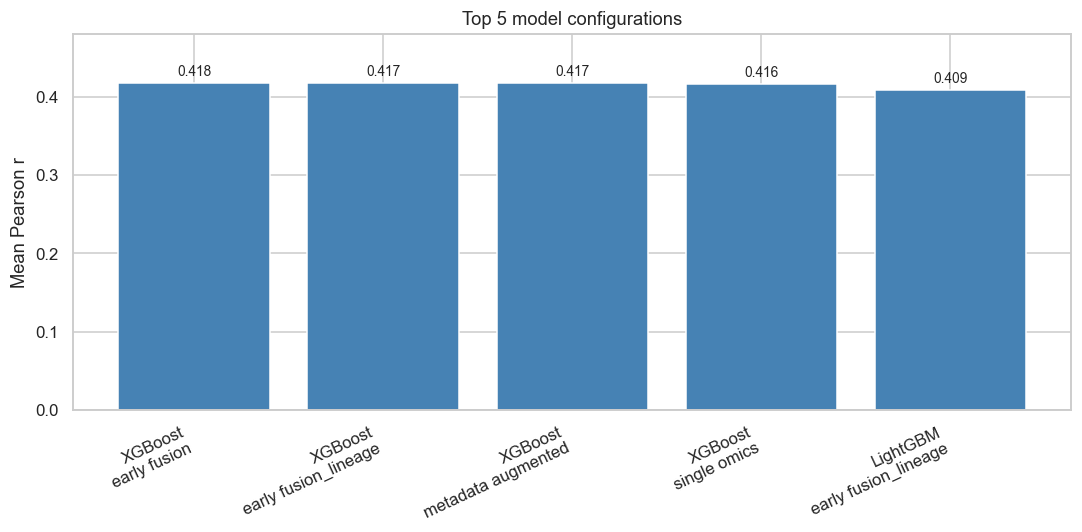

In [5]:
if top10 is None:
    config_summary = (
        cv_metrics
        .groupby(["model_family", "strategy", "omics_layer"], as_index=False)
        .agg(
            mean_pearson=("pearson", "mean"),
            mean_spearman=("spearman", "mean"),
            mean_r2=("r2", "mean"),
            mean_rmse=("rmse", "mean"),
            n_folds=("pearson", "count"),
        )
        .sort_values(["mean_pearson", "mean_spearman"], ascending=False)
        .reset_index(drop=True)
    )
    config_summary["rank"] = config_summary.index + 1
    top10 = config_summary.head(10)
elif "rank" not in top10.columns:
    top10 = top10.sort_values("mean_pearson", ascending=False).reset_index(drop=True)
    top10["rank"] = top10.index + 1

display(
    top10[["rank", "model_family", "strategy", "omics_layer",
           "mean_pearson", "mean_spearman", "mean_r2", "mean_rmse", "n_folds"]]
    .round(4)
)

best = top10.iloc[0]
print(
    f"\nBest: {best['model_family']} / {best['strategy']} / {best['omics_layer']} "
    f"(mean Pearson = {best['mean_pearson']:.4f})"
)

top5 = top10.head(5).copy()
top5["label"] = (
    top5["model_family"] + "\n" + top5["strategy"].str.replace("_", " ", n=1)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(top5["label"], top5["mean_pearson"], color="steelblue", edgecolor="white")
ax.set_ylabel("Mean Pearson r")
ax.set_title("Top 5 model configurations")
ax.set_ylim(0, top5["mean_pearson"].max() * 1.15)
for bar, val in zip(bars, top5["mean_pearson"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
save_figure(fig, "top5_model_configs.png", mirror_dirs=(PLOTS_DIR,))
plt.show()

## 3. Predicted vs observed AAC (2 example drugs)

Uses the best-ranked config from the top-10 table. Picks one well-predicted and one poorly-predicted drug.

Prediction rows for best config: 202,558
Example drugs (best / worst Pearson): ['Cytarabine', 'BRD-K42260513']
Saved: /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/plots/pred_vs_observed_examples.png


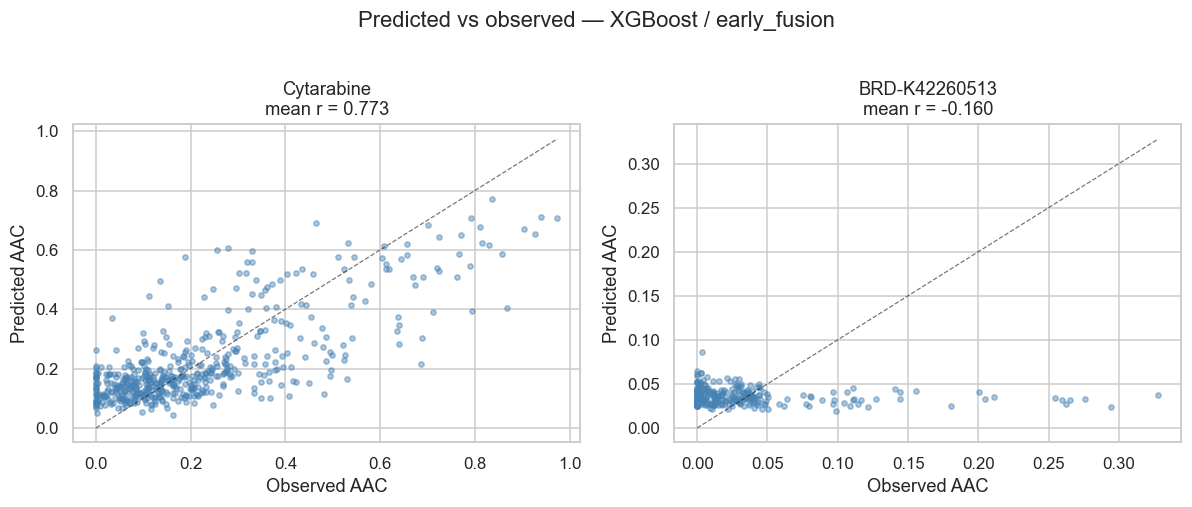

In [6]:
BEST_FAMILY = best["model_family"]
BEST_STRATEGY = best["strategy"]
BEST_LAYER = best["omics_layer"]

pred_mask = (
    (cv_predictions["model_family"] == BEST_FAMILY)
    & (cv_predictions["strategy"] == BEST_STRATEGY)
)
if "omics_layer" in cv_predictions.columns:
    pred_mask &= cv_predictions["omics_layer"] == BEST_LAYER

preds_best = cv_predictions.loc[pred_mask].copy()
print(f"Prediction rows for best config: {len(preds_best):,}")

drug_scores = (
    cv_metrics.loc[
        (cv_metrics["model_family"] == BEST_FAMILY)
        & (cv_metrics["strategy"] == BEST_STRATEGY)
        & (cv_metrics["omics_layer"] == BEST_LAYER)
    ]
    .groupby("compound")["pearson"].mean()
    .sort_values(ascending=False)
)

example_drugs = [drug_scores.index[0], drug_scores.index[-1]]
print(f"Example drugs (best / worst Pearson): {example_drugs}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, drug in zip(axes, example_drugs):
    d = preds_best[preds_best["compound"] == drug]
    ax.scatter(d["y_true"], d["y_pred"], alpha=0.45, s=12, color="steelblue")
    lims = [
        min(d["y_true"].min(), d["y_pred"].min()),
        max(d["y_true"].max(), d["y_pred"].max()),
    ]
    ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.6)
    r = drug_scores.get(drug, np.nan)
    ax.set_title(f"{drug}\nmean r = {r:.3f}")
    ax.set_xlabel("Observed AAC")
    ax.set_ylabel("Predicted AAC")

fig.suptitle(
    f"Predicted vs observed — {BEST_FAMILY} / {BEST_STRATEGY}",
    y=1.02,
)
plt.tight_layout()
save_figure(fig, "pred_vs_observed_examples.png", mirror_dirs=(PLOTS_DIR,))
plt.show()

## 4. Learned late-fusion weights

Saved: /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/plots/learned_late_fusion_weights.png


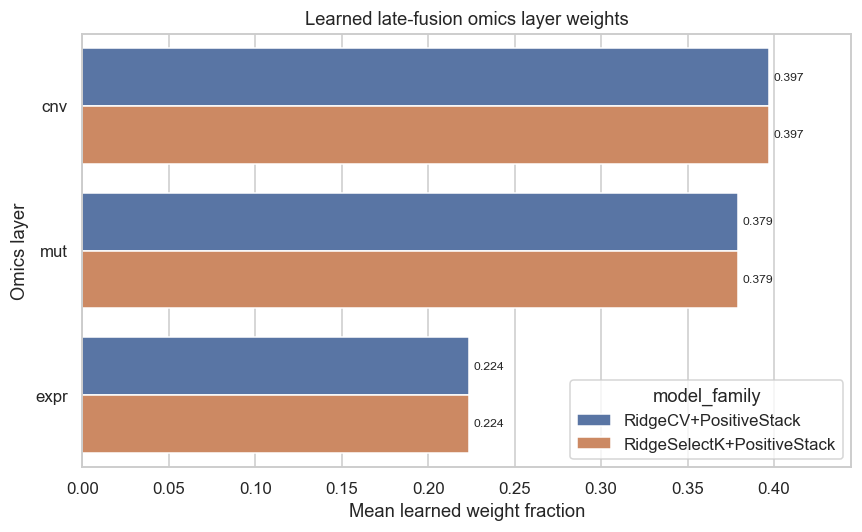

In [7]:
if learned_weights is None or learned_weights.empty:
    print("learned_late_fusion_weights.csv not found — skip this plot.")
else:
    weight_summary = (
        learned_weights
        .groupby(["model_family", "omics_layer"], as_index=False)["weight_fraction"]
        .mean()
        .sort_values(["model_family", "weight_fraction"], ascending=[True, False])
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        data=weight_summary, x="weight_fraction", y="omics_layer",
        hue="model_family", ax=ax,
    )
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)
    xmax = weight_summary["weight_fraction"].max()
    ax.set_xlim(0, xmax * 1.12)
    ax.set_xlabel("Mean learned weight fraction")
    ax.set_ylabel("Omics layer")
    ax.set_title("Learned late-fusion omics layer weights")
    plt.tight_layout()

    save_figure(fig, "learned_late_fusion_weights.png")
    plt.show()

## 5. Within-lineage performance

Uses `within_lineage_metrics.csv` if present; otherwise skips the per-lineage boxplot.

Saved: /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/plots/within_lineage_comparison.png


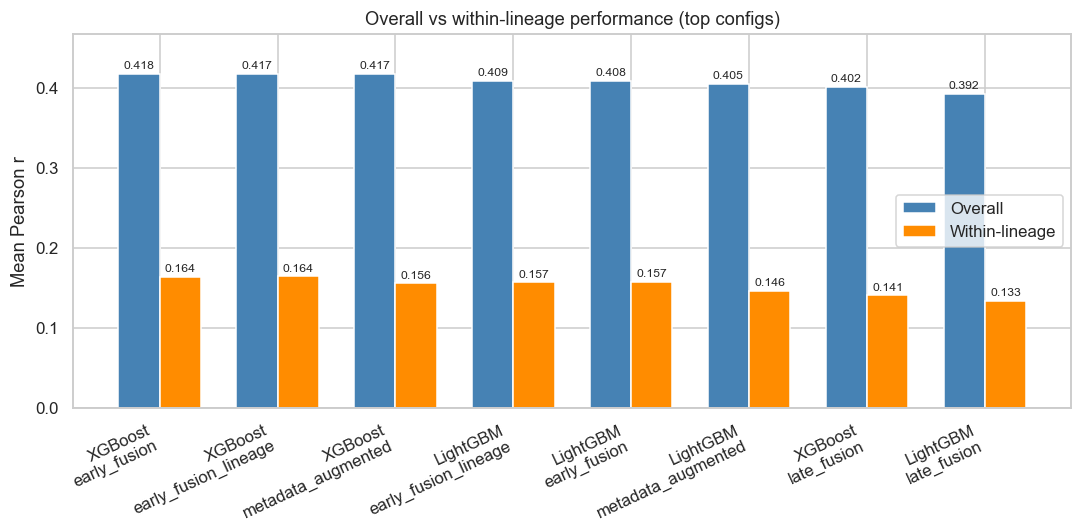

In [8]:
if within_comparison is not None and not within_comparison.empty:
    comp = within_comparison.copy()
    if "model_family" not in comp.columns:
        unnamed = [c for c in comp.columns if str(c).startswith("Unnamed")]
        if len(unnamed) >= 2:
            comp = comp.rename(columns={unnamed[0]: "model_family", unnamed[1]: "strategy"})
        elif comp.shape[1] >= 5:
            comp.columns = ["model_family", "strategy", "overall_pearson",
                            "within_lineage_pearson", "drop"][: comp.shape[1]]
    comp_top = comp.sort_values("overall_pearson", ascending=False).head(8)

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(comp_top))
    width = 0.35
    bars_overall = ax.bar(
        x - width / 2, comp_top["overall_pearson"], width,
        label="Overall", color="steelblue",
    )
    bars_within = ax.bar(
        x + width / 2, comp_top["within_lineage_pearson"], width,
        label="Within-lineage", color="darkorange",
    )
    ymax = max(comp_top["overall_pearson"].max(), comp_top["within_lineage_pearson"].max())
    for bars in (bars_overall, bars_within):
        ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)
    ax.set_ylim(0, ymax * 1.12)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r.model_family}\n{r.strategy}" for r in comp_top.itertuples()],
        rotation=25, ha="right",
    )
    ax.set_ylabel("Mean Pearson r")
    ax.set_title("Overall vs within-lineage performance (top configs)")
    ax.legend()
    plt.tight_layout()
    save_figure(fig, "within_lineage_comparison.png", mirror_dirs=(PLOTS_DIR,))
    plt.show()
else:
    print("within_lineage_comparison.csv not found — skip comparison bar chart.")

Saved: /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/plots/within_lineage_pearson.png


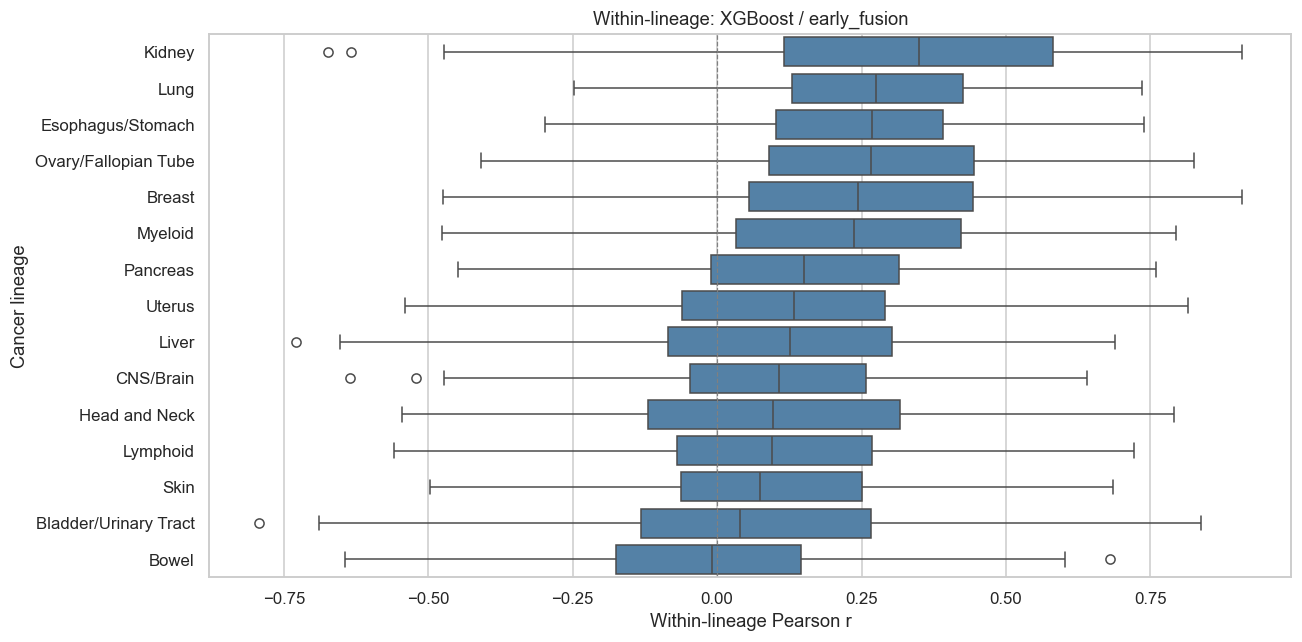

In [9]:
if within_lineage_df is None or within_lineage_df.empty:
    print("within_lineage_metrics.csv not found — skip per-lineage boxplot.")
else:
    wl_sub = within_lineage_df[
        (within_lineage_df["model_family"] == BEST_FAMILY)
        & (within_lineage_df["strategy"] == BEST_STRATEGY)
    ]
    if wl_sub.empty:
        best_combo = cv_metrics.groupby(["model_family", "strategy"])["pearson"].mean().idxmax()
        BEST_FAMILY, BEST_STRATEGY = best_combo
        wl_sub = within_lineage_df[
            (within_lineage_df["model_family"] == BEST_FAMILY)
            & (within_lineage_df["strategy"] == BEST_STRATEGY)
        ]

    top_lin = wl_sub.groupby("lineage")["pearson"].median().nlargest(15).index
    wl_plot = wl_sub[wl_sub["lineage"].isin(top_lin)]

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=wl_plot, x="pearson", y="lineage", order=list(top_lin), ax=ax, color="steelblue")
    ax.set_xlabel("Within-lineage Pearson r")
    ax.set_ylabel("Cancer lineage")
    ax.set_title(f"Within-lineage: {BEST_FAMILY} / {BEST_STRATEGY}")
    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
    plt.tight_layout()

    save_figure(fig, "within_lineage_pearson.png")
    plt.show()

## 6. SHAP / MOA plots (from `03_shap_moa_analysis_v2_426`)

Loads precomputed SHAP outputs from `data/shap_results_426/` — no SHAP recomputation needed.

Loaded eligible_compounds.csv: (426, 8)
Saved: /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/plots/moa_class_distribution.png


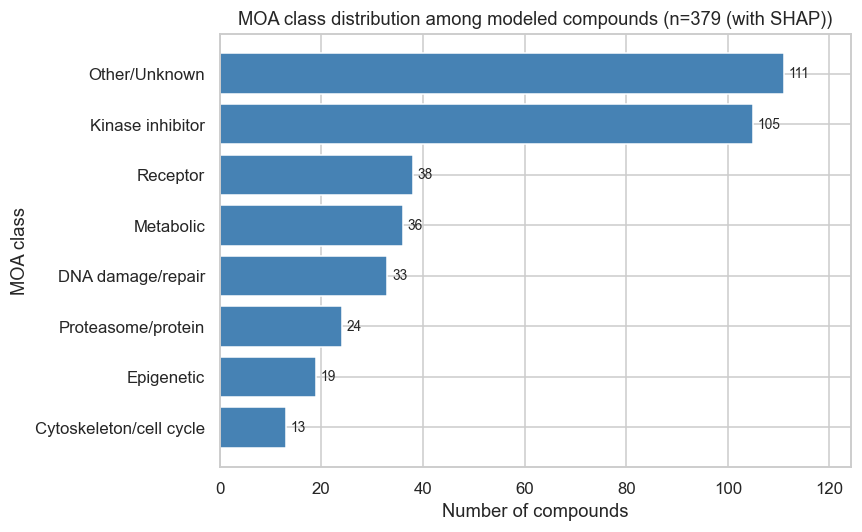

In [15]:
# --- 6.1 MOA class distribution (modeled compounds) ---
eligible = load_csv("eligible_compounds.csv")
compound_moa_path = SHAP_DIR / "compound_moa.parquet"
if not compound_moa_path.exists():
    raise FileNotFoundError(f"Missing {compound_moa_path}")

df_moa = pd.read_parquet(compound_moa_path)
df_moa_modeled = df_moa[df_moa["compound"].isin(eligible["compound"])].copy()
moa_counts = df_moa_modeled["moa_class"].value_counts()

# Restrict to compounds that actually have SHAP if parquet exists
layers_path = SHAP_DIR / "shap_per_layer_per_compound.parquet"
if layers_path.exists():
    df_shap_layers = pd.read_parquet(layers_path)
    modeled_with_shap = set(df_shap_layers.index)
    df_plot = df_moa_modeled[df_moa_modeled["compound"].isin(modeled_with_shap)]
    moa_counts = df_plot["moa_class"].value_counts()
    subtitle = f"n={len(df_plot)} (with SHAP)"
else:
    subtitle = f"n={len(df_moa_modeled)} (modeled)"

moa_sorted = moa_counts.sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(moa_sorted.index, moa_sorted.values, color="steelblue")
ax.bar_label(bars, labels=[str(v) for v in moa_sorted.values], padding=3, fontsize=9)
ax.set_xlabel("Number of compounds")
ax.set_ylabel("MOA class")
ax.set_title(f"MOA class distribution among modeled compounds ({subtitle})")
ax.set_xlim(0, moa_sorted.max() * 1.12)
plt.tight_layout()
save_figure(fig, "moa_class_distribution.png", mirror_dirs=(PLOTS_DIR, SHAP_DIR, SHAP_FIGURE_DIR))
plt.show()

Saved: /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/plots/moa_layer_importance_heatmap.png


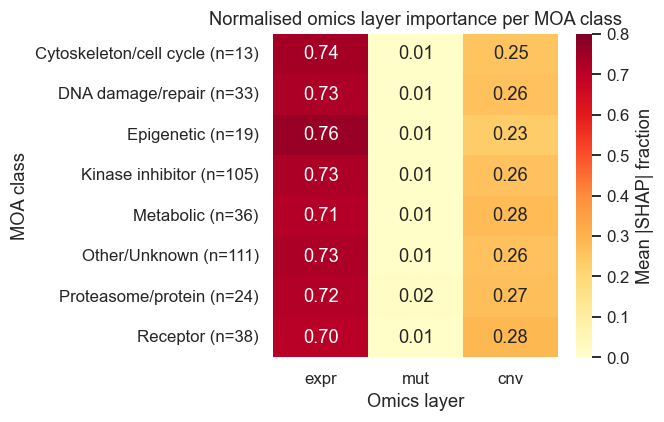

In [17]:
# --- 6.2 Omics layer importance heatmap per MOA class ---
moa_layer_path = SHAP_DIR / "moa_layer_importance.csv"
if moa_layer_path.exists():
    moa_layer_df = pd.read_csv(moa_layer_path).set_index("moa_class")
else:
    moa_layer_df = (
        df_shap_layers.groupby("moa_class")[["expr", "mut", "cnv"]]
        .mean()
        .sort_index()
    )

# Add sample sizes for axis labels
if layers_path.exists():
    sizes = df_shap_layers.groupby("moa_class").size()
    ylabels = [f"{cls} (n={sizes.get(cls, 0)})" for cls in moa_layer_df.index]
else:
    ylabels = list(moa_layer_df.index)

fig, ax = plt.subplots(figsize=(6, max(4, 0.45 * len(moa_layer_df))))
sns.heatmap(
    moa_layer_df, annot=True, fmt=".2f", cmap="YlOrRd",
    vmin=0, vmax=0.8, ax=ax, cbar_kws={"label": "Mean |SHAP| fraction"},
)
ax.set_xlabel("Omics layer")
ax.set_ylabel("MOA class")
ax.set_title("Normalised omics layer importance per MOA class")
ax.set_yticklabels(ylabels, rotation=0)
plt.tight_layout()
save_figure(fig, "moa_layer_importance_heatmap.png", mirror_dirs=(PLOTS_DIR, SHAP_DIR, SHAP_FIGURE_DIR))
plt.show()

Saved: /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/plots/moa_layer_importance_barplot.png


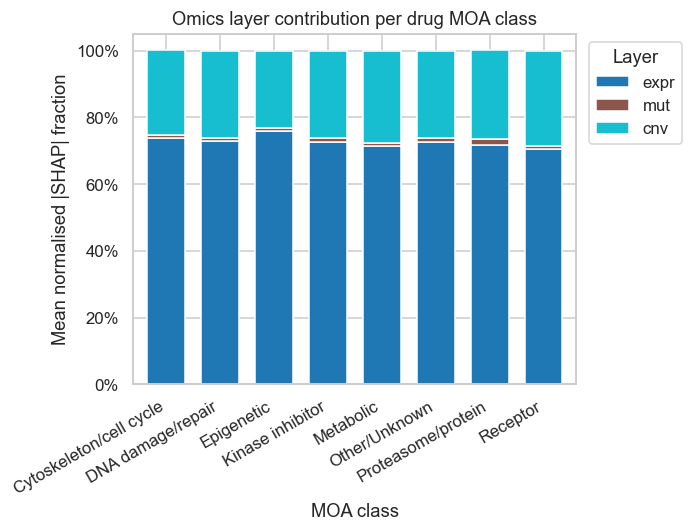

In [18]:
# --- 6.3 Stacked bar chart (layer importance) ---
fig, ax = plt.subplots(figsize=(max(6, len(moa_layer_df) * 0.8), 5))
moa_layer_df.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", width=0.7)
ax.set_xlabel("MOA class")
ax.set_ylabel("Mean normalised |SHAP| fraction")
ax.set_title("Omics layer contribution per drug MOA class")
ax.legend(title="Layer", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save_figure(fig, "moa_layer_importance_barplot.png", mirror_dirs=(PLOTS_DIR, SHAP_DIR, SHAP_FIGURE_DIR))
plt.show()

Saved: /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/plots/top_genes_per_moa_class.png


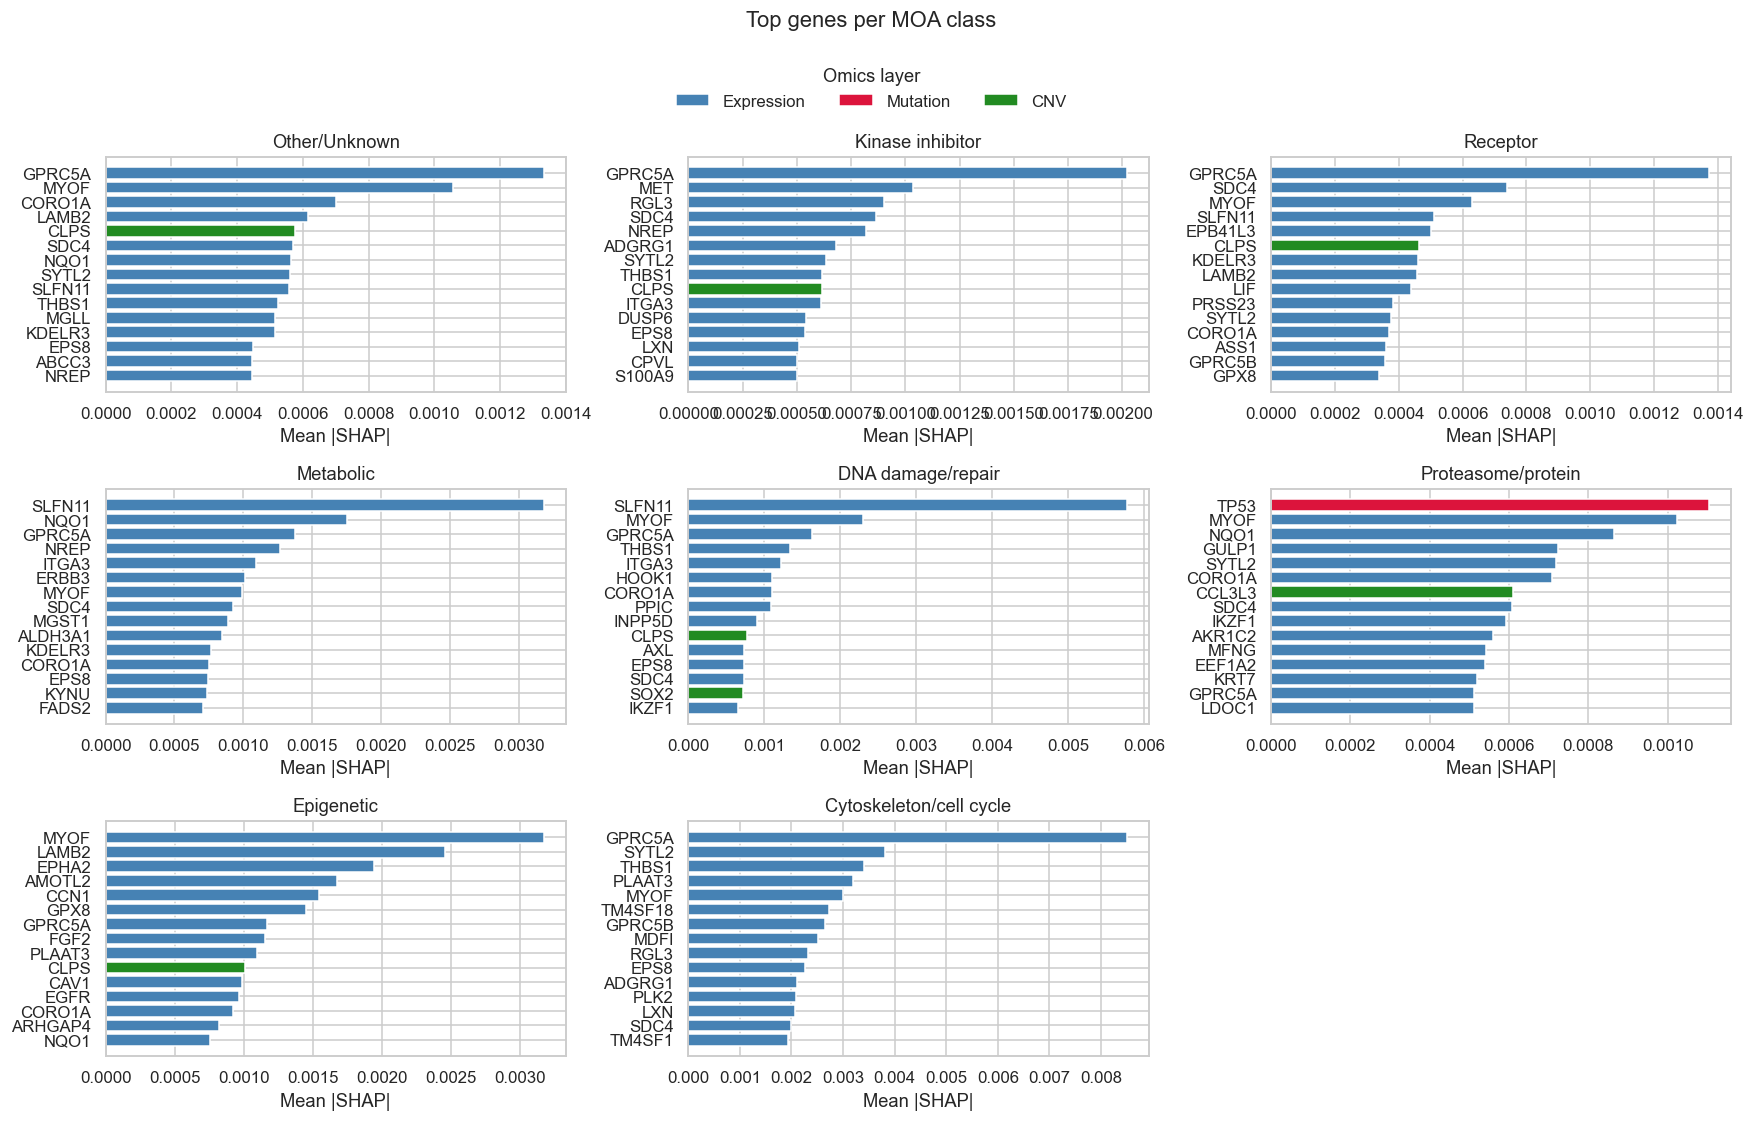

In [22]:
# --- 6.4 Top genes per MOA class (faceted bar chart) ---
from matplotlib.patches import Patch

LAYER_COLORS = {
    "expr": "steelblue",
    "mut": "crimson",
    "cnv": "forestgreen",
}

all_top_genes_path = SHAP_DIR / "all_top_genes_by_moa.csv"
if not all_top_genes_path.exists():
    raise FileNotFoundError(f"Missing {all_top_genes_path}")

all_top_genes = pd.read_csv(all_top_genes_path)
TOP_N = 15
plot_classes = (
    all_top_genes.groupby("moa_class")["n_compounds_in_class"].first()
    .sort_values(ascending=False)
    .index.tolist()
)

n_cols = 3
n_rows = int(np.ceil(len(plot_classes) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.2 * n_rows))
axes = np.atleast_1d(axes).flatten()

for ax, moa_class in zip(axes, plot_classes):
    sub = (
        all_top_genes[all_top_genes["moa_class"] == moa_class]
        .nlargest(TOP_N, "mean_abs_shap")
        .sort_values("mean_abs_shap")
    )
    labels = sub["gene_name"]
    colors = sub["omics_layer"].map(LAYER_COLORS).fillna("gray")
    ax.barh(labels, sub["mean_abs_shap"], color=colors)
    ax.set_title(f"{moa_class}")
    ax.set_xlabel("Mean |SHAP|")

for ax in axes[len(plot_classes):]:
    ax.axis("off")

legend_handles = [
    Patch(facecolor=LAYER_COLORS["expr"], label="Expression"),
    Patch(facecolor=LAYER_COLORS["mut"], label="Mutation"),
    Patch(facecolor=LAYER_COLORS["cnv"], label="CNV"),
]
fig.legend(
    handles=legend_handles,
    title="Omics layer",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False,
)
fig.suptitle("Top genes per MOA class", y=1.06)
plt.tight_layout()
save_figure(fig, "top_genes_per_moa_class.png", mirror_dirs=(PLOTS_DIR, SHAP_DIR, SHAP_FIGURE_DIR))
plt.show()

Saved: /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-AAC/plots/shap_summary_BI-2536.png


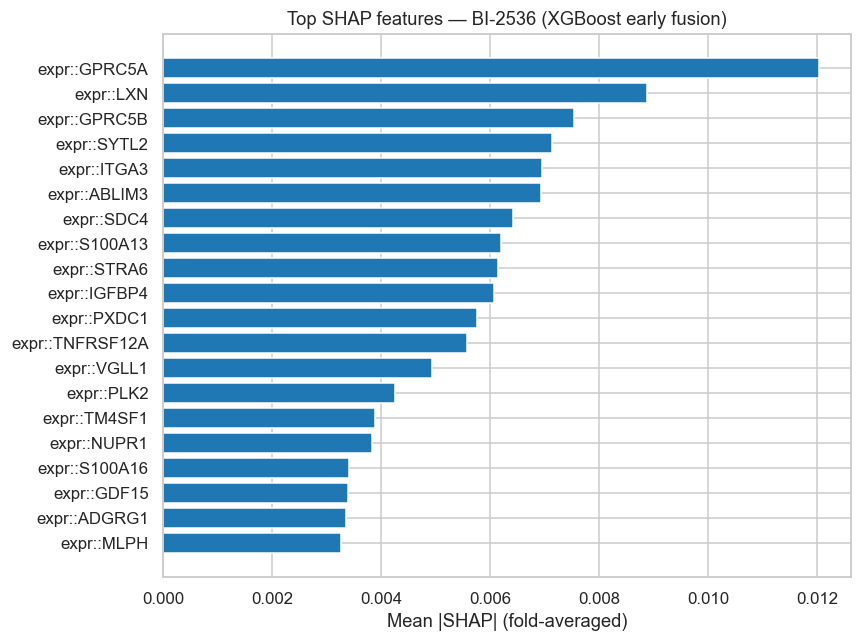

In [23]:
# --- 6.5 Example drug SHAP feature importance (BI-2536) ---
EXAMPLE_COMPOUND = "BI-2536"
genes_path = SHAP_DIR / "shap_per_gene_per_compound.parquet"
if not genes_path.exists():
    print(f"{genes_path} not found — skip example SHAP plot.")
else:
    df_shap_genes = pd.read_parquet(genes_path)
    if EXAMPLE_COMPOUND not in df_shap_genes.index:
        EXAMPLE_COMPOUND = df_shap_genes.index[0]
        print(f"BI-2536 not found; using {EXAMPLE_COMPOUND}")

    row = df_shap_genes.loc[EXAMPLE_COMPOUND].drop(labels=["moa_class"], errors="ignore")
    row = pd.to_numeric(row, errors="coerce").fillna(0.0)
    top_feats = row.abs().sort_values(ascending=False).head(20).sort_values()

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ["#1f77b4" if v >= 0 else "#d62728" for v in top_feats.values]
    ax.barh(top_feats.index.str.replace("expr::", "expr::", regex=False), top_feats.values, color=colors)
    ax.set_xlabel("Mean |SHAP| (fold-averaged)")
    ax.set_title(f"Top SHAP features — {EXAMPLE_COMPOUND} (XGBoost early fusion)")
    plt.tight_layout()
    fname = f"shap_summary_{EXAMPLE_COMPOUND.replace('/', '-')}.png"
    save_figure(fig, fname, mirror_dirs=(PLOTS_DIR, SHAP_DIR, SHAP_FIGURE_DIR))
    plt.show()

---

**Done.** Training figures → `plots/` and `RESULTS_DIR/figures/`.  
SHAP/MOA figures → `plots/` and `data/shap_results_426/` (plus `figures/`).